#### Insurance Claims Denial Prediction - Model Building

## Objective

The objective of this notebook is to build and evaluate machine learning models to predict claim denials using historical claims data.

The workflow includes:
- Feature Engineering
- Data Preprocessing
- Model Development
- Model Comparison
- Business Evaluation

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:

df = pd.read_csv("Data/claims_history.csv")

In [3]:
df.head()

,claim_id,payer_id,payer_type,visit_type,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,is_in_network,days_to_submit,missing_documentation_flag,eligibility_verified,referral_required,referral_present,split,service_month,is_denied,denial_reason
0,HCLM-00001,P008,Medicaid MCO,Outpatient,4311.44,1404.82,2,5,0,0,1,13,0,1,0,0,train,2024-06,1,Payer policy or medical necessity issue
1,HCLM-00002,P001,Commercial,Inpatient,10420.64,6065.91,6,8,1,1,0,19,0,1,1,1,train,2024-06,0,NaN
2,HCLM-00003,P010,BCBS,Outpatient,38369.33,20712.61,5,5,0,0,0,50,1,1,0,0,train,2024-02,1,Documentation incomplete or missing
3,HCLM-00004,P005,Medicare Advantage,Outpatient,6268.92,2306.49,6,3,1,1,1,7,0,1,1,1,validation,2024-09,0,NaN
4,HCLM-00005,P008,Medicaid MCO,Emergency,3986.26,1247.93,8,7,0,1,1,17,0,0,1,1,validation,2024-09,1,Patient eligibility could not be verified


#### Feature Engineering

Based on insights from the EDA, additional business-driven features are created to improve predictive performance.

In [4]:
from utils import engineer_features

In [5]:
df = engineer_features(df)

In [6]:
df.head()

,claim_id,payer_id,payer_type,visit_type,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,...,split,service_month,is_denied,denial_reason,payment_ratio,payment_gap,auth_missing,referral_missing,late_submission,service_month_num
0,HCLM-00001,P008,Medicaid MCO,Outpatient,4311.44,1404.82,2,5,0,0,...,train,2024-06-01,1,Payer policy or medical necessity issue,0.325835,2906.62,0,0,0,6
1,HCLM-00002,P001,Commercial,Inpatient,10420.64,6065.91,6,8,1,1,...,train,2024-06-01,0,NaN,0.582105,4354.73,0,0,0,6
2,HCLM-00003,P010,BCBS,Outpatient,38369.33,20712.61,5,5,0,0,...,train,2024-02-01,1,Documentation incomplete or missing,0.539822,17656.72,0,0,1,2
3,HCLM-00004,P005,Medicare Advantage,Outpatient,6268.92,2306.49,6,3,1,1,...,validation,2024-09-01,0,NaN,0.367925,3962.43,0,0,0,9
4,HCLM-00005,P008,Medicaid MCO,Emergency,3986.26,1247.93,8,7,0,1,...,validation,2024-09-01,1,Patient eligibility could not be verified,0.313058,2738.33,0,0,0,9


#### Additional Engineered Features

The following business-driven features were created based on EDA findings:

- Payment Ratio (Expected Payment / Total Billed)
- Payment Gap (Total Billed − Expected Payment)
- Authorization Missing Flag
- Referral Missing Flag
- Service Month Number
- Late Submission Flag


#### Train, Validation, Test Split

In [7]:
# train, validation, test split

train_df = df[df["split"]=="train"]

val_df = df[df["split"]=="validation"]

test_df = df[df["split"]=="test"]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(2122, 26)
(539, 26)
(539, 26)


In [8]:
print(train_df.shape)

print(val_df.shape)

print(test_df.shape)

(2122, 26)
(539, 26)
(539, 26)


In [9]:
#Feature Selection
drop_columns = [
    "claim_id",
    "split",
    "service_month",
    "is_denied",
    "denial_reason"
]

In [10]:
X_train = train_df.drop(columns=drop_columns)

X_val = val_df.drop(columns=drop_columns)

X_test = test_df.drop(columns=drop_columns)

In [11]:
y_train = train_df["is_denied"]

y_val = val_df["is_denied"]

y_test = test_df["is_denied"]

In [12]:
print(X_train.shape)

print(y_train.shape)

(2122, 21)
(2122,)


#### Pre-processing

In [13]:
numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

/var/folders/jc/m929xgk50j75ght983sl49dm0000gn/T/ipykernel_39978/2398943693.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [14]:
print(numerical_features)

print(categorical_features)

['total_billed', 'expected_payment', 'num_procedures', 'num_diagnoses', 'prior_auth_required', 'has_prior_auth', 'is_in_network', 'days_to_submit', 'missing_documentation_flag', 'eligibility_verified', 'referral_required', 'referral_present', 'payment_ratio', 'payment_gap', 'auth_missing', 'referral_missing', 'late_submission', 'service_month_num']
['payer_id', 'payer_type', 'visit_type']


#### Data Preprocessing Pipeline

A preprocessing pipeline is created to ensure that all transformations are applied consistently across training, validation, test and future prediction datasets.

- Numerical features:
    - Median Imputation
    - Standard Scaling

- Categorical features:
    - Most Frequent Imputation
    - One-Hot Encoding

In [15]:
# Pipeline for numerical features

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [16]:
# Pipeline for categorical features

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [17]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [18]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

#### Baseline Model - Logistic Regression

Logistic Regression is used as the baseline model due to its simplicity, interpretability and effectiveness for binary classification problems.

In [19]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

In [20]:
#train model
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [21]:
lr_pred = logistic_pipeline.predict(
    X_val
)


In [22]:
lr_prob = logistic_pipeline.predict_proba(
    X_val
)[:,1]

In [23]:
#Model Evaluation
print(f"Accuracy  : {accuracy_score(y_val, lr_pred):.3f}")
print(f"Precision : {precision_score(y_val, lr_pred):.3f}")
print(f"Recall    : {recall_score(y_val, lr_pred):.3f}")
print(f"F1 Score  : {f1_score(y_val, lr_pred):.3f}")
print(f"ROC AUC   : {roc_auc_score(y_val, lr_prob):.3f}")

Accuracy  : 0.839
Precision : 0.750
Recall    : 0.233
F1 Score  : 0.356
ROC AUC   : 0.713


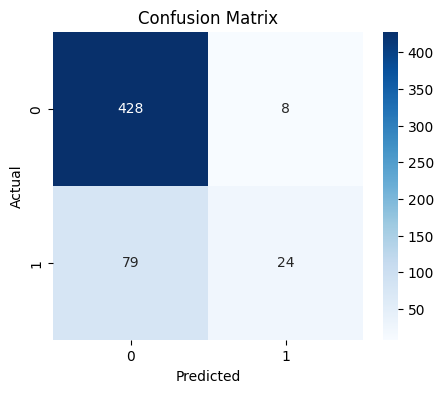

In [24]:
cm = confusion_matrix(
    y_val,
    lr_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [25]:
print(
    classification_report(
        y_val,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.98      0.91       436
           1       0.75      0.23      0.36       103

    accuracy                           0.84       539
   macro avg       0.80      0.61      0.63       539
weighted avg       0.83      0.84      0.80       539



In [26]:
def evaluate_model(model_name,
                   y_true,
                   y_pred,
                   y_prob):
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true,y_pred),
        "Precision": precision_score(y_true,y_pred),
        "Recall": recall_score(y_true,y_pred),
        "F1 Score": f1_score(y_true,y_pred),
        "ROC AUC": roc_auc_score(y_true,y_prob)
    }
    
    return results

In [27]:
model_results = []

model_results.append(
    evaluate_model(
        "Logistic Regression",
        y_val,
        lr_pred,
        lr_prob
    )
)


In [28]:
model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8385899814471243,
  'Precision': 0.75,
  'Recall': 0.23300970873786409,
  'F1 Score': 0.35555555555555557,
  'ROC AUC': 0.7128128618508952}]

#### Random Forest

In [29]:
rf_pipeline = Pipeline(

    steps=[

        ("preprocessor",preprocessor),

        (

            "classifier",

            RandomForestClassifier(

                n_estimators=200,

                max_depth=10,

                random_state=42,

                class_weight="balanced"

            )

        )

    ]

)

In [30]:
#train the model
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [31]:
rf_pred = rf_pipeline.predict(
    X_val
)

rf_prob = rf_pipeline.predict_proba(
    X_val
)[:,1]

In [32]:
print(f"Accuracy  : {accuracy_score(y_val, rf_pred):.3f}")
print(f"Precision : {precision_score(y_val, rf_pred):.3f}")
print(f"Recall    : {recall_score(y_val, rf_pred):.3f}")
print(f"F1 Score  : {f1_score(y_val, rf_pred):.3f}")
print(f"ROC AUC   : {roc_auc_score(y_val, rf_prob):.3f}")

Accuracy  : 0.814
Precision : 0.533
Recall    : 0.233
F1 Score  : 0.324
ROC AUC   : 0.679


In [33]:


model_results.append(
    evaluate_model(
        "Random Forest",
        y_val,
        rf_pred,
        rf_prob
    )
)

In [34]:
model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8385899814471243,
  'Precision': 0.75,
  'Recall': 0.23300970873786409,
  'F1 Score': 0.35555555555555557,
  'ROC AUC': 0.7128128618508952},
 {'Model': 'Random Forest',
  'Accuracy': 0.8144712430426716,
  'Precision': 0.5333333333333333,
  'Recall': 0.23300970873786409,
  'F1 Score': 0.32432432432432434,
  'ROC AUC': 0.679121760042754}]

#### Xgboost model

In [35]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                n_estimators=100,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss"
            )
        )
    ]
)

In [36]:
# Train XGBoost model
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [37]:
# Predict class labels
xgb_pred = xgb_pipeline.predict(X_val)

In [38]:
# Predict probability of claim denial
xgb_prob = xgb_pipeline.predict_proba(X_val)[:, 1]

In [39]:
print("Accuracy :", round(accuracy_score(y_val, xgb_pred),3))
print("Precision:", round(precision_score(y_val, xgb_pred),3))
print("Recall   :", round(recall_score(y_val, xgb_pred),3))
print("F1 Score :", round(f1_score(y_val, xgb_pred),3))
print("ROC AUC  :", round(roc_auc_score(y_val, xgb_prob),3))

Accuracy : 0.813
Precision: 0.528
Recall   : 0.184
F1 Score : 0.273
ROC AUC  : 0.678


In [40]:
model_results.append(
    evaluate_model(
        "Xgboost",
        y_val,
        xgb_pred,
        xgb_prob
    )
)

In [41]:
model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8385899814471243,
  'Precision': 0.75,
  'Recall': 0.23300970873786409,
  'F1 Score': 0.35555555555555557,
  'ROC AUC': 0.7128128618508952},
 {'Model': 'Random Forest',
  'Accuracy': 0.8144712430426716,
  'Precision': 0.5333333333333333,
  'Recall': 0.23300970873786409,
  'F1 Score': 0.32432432432432434,
  'ROC AUC': 0.679121760042754},
 {'Model': 'Xgboost',
  'Accuracy': 0.8126159554730983,
  'Precision': 0.5277777777777778,
  'Recall': 0.18446601941747573,
  'F1 Score': 0.2733812949640288,
  'ROC AUC': 0.6784314598735193}]

#### Model Comparison

In [42]:
comparison_df = pd.DataFrame(
    model_results
)

In [43]:
comparison_df = comparison_df.round(3)

In [44]:
comparison_df.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.839,0.750,0.233,0.356,0.713
1,Random Forest,0.814,0.533,0.233,0.324,0.679
2,Xgboost,0.813,0.528,0.184,0.273,0.678


## Business Threshold Analysis

The default classification threshold of 0.50 may not align with the operational workflow.

Since the claims review team can manually review only the highest-risk 25% of claims, the model is evaluated based on its ability to rank claims by predicted denial probability.

In [45]:
validation_results = pd.DataFrame({
    "actual_denial": y_val,
    "denial_probability": lr_prob
})

In [46]:
validation_results = validation_results.sort_values(
    by="denial_probability",
    ascending=False
).reset_index(drop=True)
print(validation_results)

     actual_denial  denial_probability
0                1            0.882100
1                1            0.839784
2                1            0.820265
3                1            0.794682
4                0            0.736512
..             ...                 ...
534              0            0.038961
535              0            0.037490
536              0            0.036009
537              0            0.032636
538              0            0.032324

[539 rows x 2 columns]


In [47]:
#top25%
review_limit = int(len(validation_results) * 0.25)

print(f"Claims reviewed: {review_limit}")

Claims reviewed: 134


In [48]:
print(validation_results.head(134))

     actual_denial  denial_probability
0                1            0.882100
1                1            0.839784
2                1            0.820265
3                1            0.794682
4                0            0.736512
..             ...                 ...
129              0            0.275084
130              0            0.274563
131              0            0.271063
132              0            0.270879
133              0            0.270460

[134 rows x 2 columns]


In [49]:
validation_results["review_flag"] = 0

validation_results.loc[
    :review_limit-1,
    "review_flag"
] = 1

In [50]:
total_denials = validation_results["actual_denial"].sum()

captured_denials = validation_results.loc[
    validation_results["review_flag"] == 1,
    "actual_denial"
].sum()

capture_rate = captured_denials / total_denials

print(f"Total Denied Claims   : {total_denials}")
print(f"Denied Claims Captured: {captured_denials}")
print(f"Capture Rate          : {capture_rate:.2%}")

Total Denied Claims   : 103
Denied Claims Captured: 50
Capture Rate          : 48.54%


### Business Interpretation

Using the predicted denial probabilities to rank claims, reviewing only the top 25% highest-risk claims captures approximately **48.5% of all denied claims** in the validation dataset.

This prioritization strategy aligns with the operational constraint of limited manual review capacity while maximizing the number of denied claims identified before submission.

#### Final Model Selection


Three machine learning models were evaluated on the validation dataset.

Logistic Regression achieved the highest ROC-AUC while providing a simple and interpretable model. It also demonstrated strong business performance by capturing approximately 49% of denied claims within the top 25% highest-risk predictions.

Therefore, Logistic Regression was selected as the final model.

#### Retrain Final Model

In [51]:
# Combine train and validation data

train_final = pd.concat(
    [train_df, val_df],
    axis=0
)

In [52]:
# Create final training dataset

X_train_final = train_final.drop(
    columns=drop_columns
)

y_train_final = train_final["is_denied"]

In [53]:
# Train final Logistic Regression model

logistic_pipeline.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

# Final Model Evaluation

The selected model is evaluated on the unseen test dataset to estimate its generalization performance.

In [54]:
test_pred = logistic_pipeline.predict(
    X_test
)

test_prob = logistic_pipeline.predict_proba(
    X_test
)[:,1]

In [55]:
print(f"Accuracy  : {accuracy_score(y_test, test_pred):.3f}")
print(f"Precision : {precision_score(y_test, test_pred):.3f}")
print(f"Recall    : {recall_score(y_test, test_pred):.3f}")
print(f"F1 Score  : {f1_score(y_test, test_pred):.3f}")
print(f"ROC AUC   : {roc_auc_score(y_test, test_prob):.3f}")

Accuracy  : 0.766
Precision : 0.750
Recall    : 0.150
F1 Score  : 0.250
ROC AUC   : 0.703


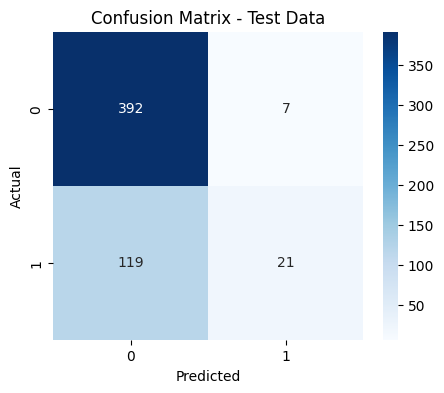

In [56]:
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Test Data")

plt.show()

In [57]:
print(
    classification_report(
        y_test,
        test_pred
    )
)

              precision    recall  f1-score   support

           0       0.77      0.98      0.86       399
           1       0.75      0.15      0.25       140

    accuracy                           0.77       539
   macro avg       0.76      0.57      0.56       539
weighted avg       0.76      0.77      0.70       539



In [58]:
# Calculate threshold corresponding to top 25% highest-risk claims

threshold = np.quantile(
    test_prob,
    0.75
)

print(f"Selected Threshold: {threshold:.3f}")

Selected Threshold: 0.268


In [59]:
test_pred_threshold = (
    test_prob >= threshold
).astype(int)

In [60]:
print(f"Threshold : {threshold:.3f}")
print(f"Accuracy  : {accuracy_score(y_test, test_pred_threshold):.3f}")
print(f"Precision : {precision_score(y_test, test_pred_threshold):.3f}")
print(f"Recall    : {recall_score(y_test, test_pred_threshold):.3f}")
print(f"F1 Score  : {f1_score(y_test, test_pred_threshold):.3f}")
print(f"ROC AUC   : {roc_auc_score(y_test, test_prob):.3f}")

Threshold : 0.268
Accuracy  : 0.746
Precision : 0.511
Recall    : 0.493
F1 Score  : 0.502
ROC AUC   : 0.703


In [61]:
print(
    classification_report(
        y_test,
        test_pred_threshold
    )
)

              precision    recall  f1-score   support

           0       0.82      0.83      0.83       399
           1       0.51      0.49      0.50       140

    accuracy                           0.75       539
   macro avg       0.67      0.66      0.67       539
weighted avg       0.74      0.75      0.74       539



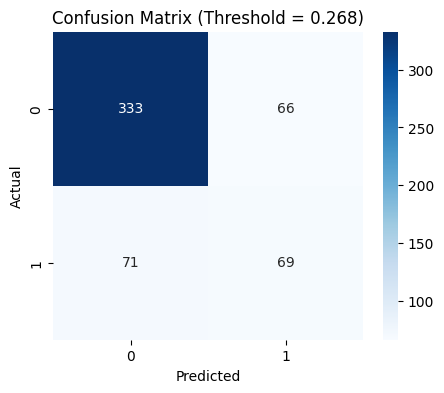

In [62]:
cm = confusion_matrix(
    y_test,
    test_pred_threshold
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Threshold = {threshold:.3f})")

plt.show()

In [63]:
test_results = pd.DataFrame({
    "actual_denial": y_test,
    "denial_probability": test_prob
})

In [64]:
test_results = test_results.sort_values(
    by="denial_probability",
    ascending=False
).reset_index(drop=True)

In [65]:
review_limit = int(len(test_results) * 0.25)

test_results["review_flag"] = 0

test_results.loc[:review_limit-1, "review_flag"] = 1

In [66]:
total_denials = test_results["actual_denial"].sum()

captured_denials = test_results.loc[
    test_results["review_flag"] == 1,
    "actual_denial"
].sum()

capture_rate = captured_denials / total_denials

print(f"Claims Reviewed (25%): {review_limit}")
print(f"Total Denials: {total_denials}")
print(f"Captured Denials: {captured_denials}")
print(f"Denial Capture Rate: {capture_rate:.2%}")

Claims Reviewed (25%): 134
Total Denials: 140
Captured Denials: 68
Denial Capture Rate: 48.57%


### Business Performance

When the review team inspects only the highest-risk 25% of claims, the model captures approximately **49%** of all denied claims in the unseen test dataset.

This demonstrates that the model effectively prioritizes claims for manual review while operating within the team's review capacity.

#### Save the model

In [67]:
import joblib

In [68]:
# Save final model

joblib.dump(
    logistic_pipeline,
    "models/logistic_model.pkl"
)

['models/logistic_model.pkl']

In [69]:
feature_names = logistic_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

In [70]:
coefficients = logistic_pipeline.named_steps[
    "classifier"
].coef_[0]

In [71]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

In [72]:
importance_df["abs_coefficient"] = (
    importance_df["coefficient"].abs()
)

In [73]:
importance_df = importance_df.sort_values(
    by="abs_coefficient",
    ascending=False
)

In [74]:
importance_df.head(20)

,feature,coefficient,abs_coefficient
18,cat__payer_id_P001,-0.482463,0.482463
14,num__auth_missing,0.474898,0.474898
8,num__missing_documentation_flag,0.411793,0.411793
25,cat__payer_id_P008,0.400386,0.400386
20,cat__payer_id_P003,0.365363,0.365363
31,cat__payer_type_Commercial,-0.316660,0.316660
28,cat__payer_id_P011,-0.276298,0.276298
9,num__eligibility_verified,-0.259924,0.259924
32,cat__payer_type_Medicaid MCO,0.212909,0.212909
23,cat__payer_id_P006,0.190616,0.190616


In [75]:
importance_df.to_csv(
    "models/feature_importance.csv",
    index=False
)